In [ ]:
!pip install -q unsloth pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.1/26.1 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/1

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [ ]:
from unsloth import FastLanguageModel

MODEL_NAME = "walter-bd/npc-voice-v5-sft"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=256,
)

FastLanguageModel.for_inference(model)

print("모델 로딩 완료!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.14: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

모델 로딩 완료!


In [ ]:
characters = [
    {
        "character": "까칠한 대장장이",
        "tone": "grumpy",
        "style": "blunt",
        "humor": "none",
        "relation": "stranger",
        "role": "blacksmith"
    },

    {
        "character": "유쾌한 상인",
        "tone": "cheerful",
        "style": "verbose",
        "humor": "warm",
        "relation": "friend",
        "role": "merchant"
    },

    {
        "character": "겁쟁이 주민",
        "tone": "fearful",
        "style": "rambling",
        "humor": "none",
        "relation": "stranger",
        "role": "peasant"
    },

    {
        "character": "현명한 학자",
        "tone": "wise",
        "style": "poetic",
        "humor": "dry",
        "relation": "acquaintance",
        "role": "scholar"
    },

    {
        "character": "거만한 귀족",
        "tone": "proud",
        "style": "blunt",
        "humor": "sarcastic",
        "relation": "stranger",
        "role": "noble"
    },

    {
        "character": "장난스러운 여관주인",
        "tone": "playful",
        "style": "short",
        "humor": "dry",
        "relation": "friend",
        "role": "innkeeper"
    }
]

print("캐릭터 수:", len(characters))

캐릭터 수: 6


In [ ]:
facts = [
    "Iron swords cost 15 gold.",
    "A dragon appeared near the northern village.",
    "The king disappeared three days ago.",
    "The inn closes at midnight.",
    "A treasure is hidden beneath the old temple."
]

print("FACT 수:", len(facts))
print("총 생성 수:", len(facts) * len(characters))

FACT 수: 5
총 생성 수: 30


In [ ]:
import torch
import time

def generate_npc(fact, character, max_new_tokens=80):

    prompt = (
        f"TONE:{character['tone']} "
        f"STYLE:{character['style']} "
        f"HUMOR:{character['humor']} "
        f"RELATION:{character['relation']} "
        f"ROLE:{character['role']}\n"
        f"FACT: {fact}\n"
        f"OUT:"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    start_time = time.time()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    elapsed = time.time() - start_time

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    text = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    # 혹시 다음 prompt를 이어서 출력하는 경우 제거
    if "\nFACT:" in text:
        text = text.split("\nFACT:")[0].strip()

    if "\nTONE:" in text:
        text = text.split("\nTONE:")[0].strip()

    return text, elapsed

In [ ]:
import pandas as pd

results = []

for fact_id, fact in enumerate(facts, start=1):

    print("=" * 80)
    print(f"FACT {fact_id}: {fact}")
    print("=" * 80)

    for character in characters:

        output, elapsed = generate_npc(
            fact=fact,
            character=character
        )

        results.append({
            "fact_id": fact_id,
            "fact": fact,
            "character": character["character"],
            "tone": character["tone"],
            "style": character["style"],
            "humor": character["humor"],
            "relation": character["relation"],
            "role": character["role"],
            "output": output,
            "generation_time": elapsed
        })

        print()
        print(character["character"])
        print("→", output)
        print(f"생성 시간: {elapsed:.2f}s")

Both `max_new_tokens` (=80) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FACT 1: Iron swords cost 15 gold.


Both `max_new_tokens` (=80) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



까칠한 대장장이
→ "Okay, fine. But I'm a blacksmith. Iron swords cost 15 gold. You're asking me for a sword, but you're not paying the price. If you want a sword, you pay 15 gold."
생성 시간: 8.67s


Both `max_new_tokens` (=80) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


겁쟁이 주민
→ A treasure is hidden beneath the old temple... I fear that is the truth!
생성 시간: 1.02s


Both `max_new_tokens` (=80) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



현명한 학자
→ A treasure lies beneath the old temple, a hidden treasure waiting for discovery.
생성 시간: 1.14s


Both `max_new_tokens` (=80) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



거만한 귀족
→ I know it. A treasure is hidden beneath the old temple, and it's a big one.
생성 시간: 4.66s

장난스러운 여관주인
→ A treasure is hidden beneath the old temple, and I can tell you, it's a big deal!
생성 시간: 1.38s


In [ ]:
df = pd.DataFrame(results)

df[
    [
        "fact_id",
        "character",
        "fact",
        "output",
        "generation_time"
    ]
]

,fact_id,character,fact,output,generation_time
0,1,까칠한 대장장이,Iron swords cost 15 gold.,"""Okay, fine. But I'm a blacksmith. Iron swords...",8.667485
1,1,유쾌한 상인,Iron swords cost 15 gold.,"I see you're in love with Iron swords, and I'm...",1.889931
2,1,겁쟁이 주민,Iron swords cost 15 gold.,I'm so scared of the price! Iron swords cost 1...,1.306980
3,1,현명한 학자,Iron swords cost 15 gold.,"""Iron swords cost 15 gold, but they're worth it.""",1.132578
4,1,거만한 귀족,Iron swords cost 15 gold.,"I told you so, dear friend. Iron swords cost 1...",1.919152
5,1,장난스러운 여관주인,Iron swords cost 15 gold.,"Iron swords cost 15 gold, just like you're use...",0.961061
6,2,까칠한 대장장이,A dragon appeared near the northern village.,"A dragon appeared near the northern village, a...",1.734837
7,2,유쾌한 상인,A dragon appeared near the northern village.,I am so happy to see a dragon appear near the ...,0.917102
8,2,겁쟁이 주민,A dragon appeared near the northern village.,I saw a dragon appear near the northern villag...,1.176833
9,2,현명한 학자,A dragon appeared near the northern village.,"A dragon appeared near the northern village, a...",1.032032


In [ ]:
df.to_csv(
    "npc_baseline_results.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
!apt-get -qq update
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 찾기
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# Matplotlib에 폰트 등록
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트 설정 완료")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 127332 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
한글 폰트 설정 완료


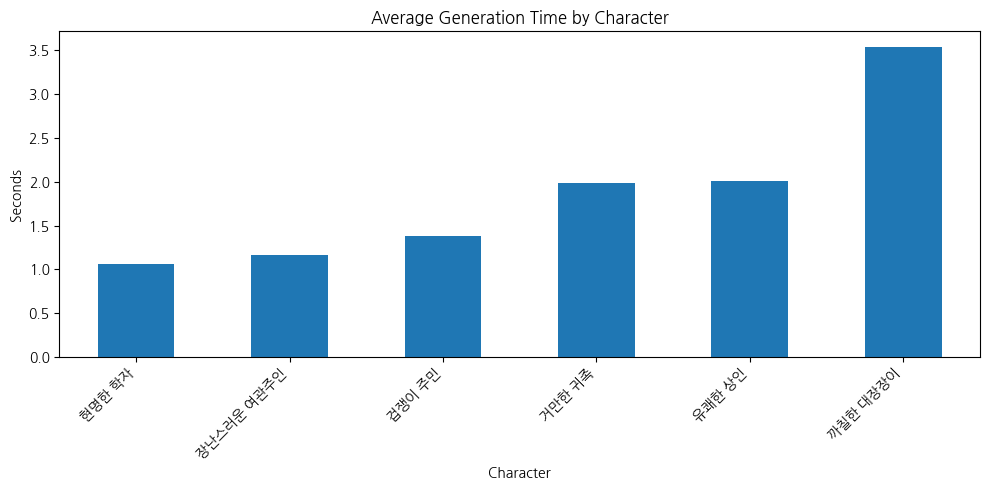

In [ ]:
import matplotlib.pyplot as plt

time_by_character = (
    df.groupby("character")["generation_time"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10, 5))
time_by_character.plot(kind="bar")

plt.title("Average Generation Time by Character")
plt.ylabel("Seconds")
plt.xlabel("Character")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

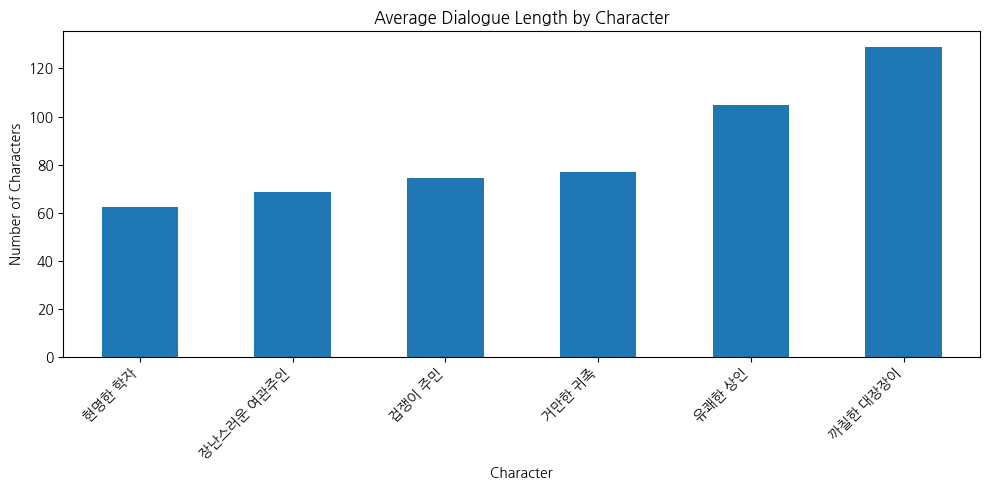

In [ ]:
df["output_length"] = df["output"].str.len()

length_by_character = (
    df.groupby("character")["output_length"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10, 5))
length_by_character.plot(kind="bar")

plt.title("Average Dialogue Length by Character")
plt.ylabel("Number of Characters")
plt.xlabel("Character")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
for fact_id in sorted(df["fact_id"].unique()):

    temp = df[df["fact_id"] == fact_id]

    print("\n" + "=" * 100)
    print("FACT:", temp.iloc[0]["fact"])
    print("=" * 100)

    for _, row in temp.iterrows():

        print(f"\n[{row['character']}]")
        print(
            f"TONE={row['tone']} / "
            f"STYLE={row['style']} / "
            f"HUMOR={row['humor']} / "
            f"RELATION={row['relation']} / "
            f"ROLE={row['role']}"
        )

        print("→", row["output"])


FACT: Iron swords cost 15 gold.

[까칠한 대장장이]
TONE=grumpy / STYLE=blunt / HUMOR=none / RELATION=stranger / ROLE=blacksmith
→ "Okay, fine. But I'm a blacksmith. Iron swords cost 15 gold. You're asking me for a sword, but you're not paying the price. If you want a sword, you pay 15 gold."

[유쾌한 상인]
TONE=cheerful / STYLE=verbose / HUMOR=warm / RELATION=friend / ROLE=merchant
→ I see you're in love with Iron swords, and I'm glad you're so happy with 15 gold, which makes the cost right.

[겁쟁이 주민]
TONE=fearful / STYLE=rambling / HUMOR=none / RELATION=stranger / ROLE=peasant
→ I'm so scared of the price! Iron swords cost 15 gold, and that's it!

[현명한 학자]
TONE=wise / STYLE=poetic / HUMOR=dry / RELATION=acquaintance / ROLE=scholar
→ "Iron swords cost 15 gold, but they're worth it."

[거만한 귀족]
TONE=proud / STYLE=blunt / HUMOR=sarcastic / RELATION=stranger / ROLE=noble
→ I told you so, dear friend. Iron swords cost 15 gold. And you know what that means.

[장난스러운 여관주인]
TONE=playful / STYLE=short / HU